# Taller - Clasificación de sistemas

## 1) Clasificación de sistemas

Clasifica los sistemas dados a continuación en cada eje y justifica en 1–2 líneas cada elección:

- Estático / Dinámico

- Determinista / Estocástico

- Continuo / Discreto / Híbrido

- Abierto / Cerrado


### a) Microservicio

Un microservicio en producción recibe peticiones con picos diarios; los tiempos de servicio tienen distribución lognormal (cola pesada); el sistema hace autoescalado cuando la latencia supera un umbral.

**Respuesta:**  Dinámico, estocástico, híbrido y abierto

El microservicio responde a un entorno cambiante; durante el día puede recibir más o menos tráfico y, en función de eso, la latencia varía con el tiempo

Los tiempos de servicio no son fijos, siguen una distribución lognormal con colas pesadas; por eso, aun con la misma carga, los resultados pueden variar.

La latencia y la carga evolucionan de forma continua, pero el autoescalado ocurre en eventos discretos, ya que se activa únicamente cuando la latencia supera un umbral.

Al estar en producción, recibe peticiones externas y entrega respuestas; su comportamiento depende directamente de la interacción con los usuarios y del entorno de infraestructura.

### b) Plataforma de streaming con picos y reintentos

Una plataforma de streaming recibe picos diarios de tráfico. Los clientes realizan reintentos con espera exponencial después de que se agota el tiempo de espera. El servicio activa el autoescalado cuando la latencia supera un umbral. Los tiempos de servicio siguen una distribución lognormal (de cola pesada).

**Respuesta:** Dinámico, estocástico, híbrido y abierto

La plataforma de streaming recibe tráfico que cambia a lo largo del día y además las condiciones del sistema (latencia, autoescalado, reintentos) evolucionan con el tiempo.

Los tiempos de servicio siguen una distribución lognormal con colas pesadas, y los reintentos de clientes introducen aún más incertidumbre en la carga total.

Variables como tráfico y latencia cambian de forma continua, pero el autoescalado y los reintentos se producen como eventos discretos (se disparan en momentos puntuales).

La plataforma depende de la interacción con el entorno: recibe solicitudes de clientes y devuelve respuestas; sin usuarios externos no tendría actividad.

### c) Control térmico en un clúster

Un clúster de computo ajusta ventiladores y frecuencia de CPU según la temperatura. La dinámica térmica se modela con una **ODE** y los actuadores cambian en **umbrales**. La carga y la temperatura ambiente varían.

**Respuesta:** Dinámico, determinista, híbrido y abierto

La temperatura y el estado del clúster cambian con el tiempo según la carga, el ambiente y las acciones de control.

La dinámica térmica se modela con una ODE y los actuadores se activan por reglas de umbral; bajo las mismas condiciones iniciales y entradas, siempre se obtiene el mismo resultado.

La evolución térmica es continua (modelada con ecuaciones diferenciales), pero los cambios de ventiladores y frecuencia de CPU ocurren en saltos discretos al cruzar umbrales.

El clúster interactúa con el entorno: recibe carga de trabajo y está expuesto a la temperatura ambiente, lo que afecta directamente su comportamiento.


### d) Almacén robotizado con navegación

Robots móviles siguen trayectorias suaves pero realizan paradas/evitaciones usando sensores. Llegan nuevos pedidos desde fuera y se despachan paquetes al exterior. Los sensores tienen usados por los robots tienen ruido.

**Respuesta:** Dinámico, estocástico, híbrido y abierto

El robot se mueve siguiendo trayectorias que cambian con el tiempo, y su estado varía al detenerse o esquivar obstáculos.

Los sensores tienen ruido, lo que introduce incertidumbre en la percepción y en las decisiones de movimiento.

El desplazamiento del robot es continuo (trayectorias suaves), pero las paradas y evitaciones ocurren en eventos discretos al detectar obstáculos.

El sistema recibe pedidos desde fuera y despacha paquetes al exterior, interactuando directamente con su entorno.

### e) Mesa de ayuda con abandono y reintentos

Un sistema de soporte recibe tickets desde Internet con una tasa no estacionaria. Algunos usuarios abandonan si esperan demasiado tiempo y otros reintentan más tarde. El enrutador prioriza tickets críticos.


**Respuesta:** Dinámico, estocástico, discreto y abierto

Dinámico, porque el estado del sistema cambia con el tiempo: llegan tickets, usuarios esperan, algunos abandonan o reintentan, y el enrutador prioriza tickets críticos.

Estocástico, porque la llegada de tickets es aleatoria (tasa no estacionaria), los abandonos y reintentos de usuarios son probabilísticos y no se pueden predecir con exactitud.

Discreto, porque los eventos (llegada de tickets, atención, abandono) ocurren en unidades individuales y contables, no de forma continua.

Abierto, porque el sistema interactúa con el entorno externo: recibe tickets de Internet y los usuarios pueden abandonar o reintentar desde fuera del sistema.

## 2) Realice todos los ejercicios practicos dejados al final de los jupyters notebooks dados en clase

## Jupiter Notebook clase 2

In [1]:
try:
    from pint import UnitRegistry
except ImportError:
    !pip install pint
from numpy import sqrt
from pint import UnitRegistry


units = UnitRegistry()
meter = units.meter
second = units.second

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 305.5/305.5 kB 12.1 MB/s eta 0:00:00


### Ejercicio 1

En notación matemática, podemos escribir una ecuación como $v = a t$ y se entiende que estamos multiplicando $a$ y $t$. Pero eso no funciona en Python.  Si pones dos variables una al lado de la otra, así:

```
v = a t
```

obtendrás un *error de sintaxis*, lo que significa que hay algo mal en tu programa. Pruébalo para ver cómo se ve el mensaje de error.

In [4]:
a = 9.8 * meter / second**2
t = 3.4 * second

v = a * t
v

<Quantity(33.32, 'meter / second')>

### Ejercicio 2

En este capítulo usamos la función `sqrt` de la biblioteca NumPy.  NumPy también proporciona una variable llamada `pi` que contiene una aproximación de la constante matemática $\pi$.
Podemos importarla así:

In [5]:
from numpy import pi
pi

3.141592653589793

NumPy proporciona otras funciones que usaremos, incluidas `log`, `exp`, `sin` y `cos`.
Importa `sin` y `cos` de NumPy y calcula

$$sin^2 (\pi/4) + cos^2 (\pi/4)$$

Nota: Una identidad matemática nos dice que la respuesta debe ser $1$.

In [6]:
# Importamos las funciones necesarias de NumPy
from numpy import sin, cos, pi

# Calculamos la expresión
resultado = sin(pi/4)**2 + cos(pi/4)**2

# Mostramos el resultado
print("sin^2(pi/4) + cos^2(pi/4) =", resultado)

sin^2(pi/4) + cos^2(pi/4) = 1.0


Explicación:
1. sin(pi/4) nos da el valor del seno de 45°.

2. cos(pi/4) nos da el valor del coseno de 45°.

3. Elevamos cada uno al cuadrado y los sumamos.

4. Por la regla de trigonometría, el resultado siempre será 1.

### Ejercicio 3

Supón que llevas un poste de 10 pies a la cima del Empire State Building y lo usas para soltar el centavo desde una altura 10 pies menor. ¿Cuánto más rápido llegaría al suelo? ¿Y cuál sería su velocidad de impacto?


In [7]:
h = 381 * meter

In [ ]:
from pint import UnitRegistry
from numpy import sqrt

# Crear registro de unidades
units = UnitRegistry()
meter = units.meter
second = units.second
foot = units.foot

# Aceleración debido a la gravedad
a = 9.8 * meter / second**2

# Altura original del Empire State Building
h_original = 381 * meter

# Altura reducida (10 pies menos)
h_reducida = h_original - 10 * foot

# Tiempo de caída con fórmula t = sqrt(2*h/a)
t_original = sqrt(2 * h_original / a)
t_reducida = sqrt(2 * h_reducida / a)

# Velocidad al impactar: v = a * t
v_original = a * t_original
v_reducida = a * t_reducida

# Diferencia de tiempo
delta_t = t_original - t_reducida

# Mostrar resultados
print("Tiempo de caída desde altura original:", t_original)
print("Velocidad al impactar desde altura original:", v_original)
print("Tiempo de caída desde altura reducida:", t_reducida)
print("Velocidad al impactar desde altura reducida:", v_reducida)
print("Diferencia en tiempo de caída:", delta_t)


Tiempo de caída desde altura original: 8.817885349720552 second
Velocidad al impactar desde altura original: 86.41527642726142 meter / second
Tiempo de caída desde altura reducida: 8.78254298164773 second
Velocidad al impactar desde altura reducida: 86.06892122014776 meter / second
Diferencia en tiempo de caída: 0.035342368072821984 second


¿Cuánto más rápido llegaría al suelo?
Aproximadamente 0.035 segundos más rápido.

¿Cuál sería su velocidad de impacto?
Aproximadamente 86.07 m/s.

### Ejercicio 4

¿Por qué no tendría sentido sumar `a` y `t`? ¿Qué ocurre si lo intentas?

In [8]:
a = 9.8 * meter / second**2
t = 3.4 * second

In [40]:
# Ejemplo
from pint import UnitRegistry

units = UnitRegistry()
meter = units.meter
second = units.second

a = 9.8 * meter / second**2
t = 3.4 * second

print(a + t)

DimensionalityError: Cannot convert from 'meter / second ** 2' ([length] / [time] ** 2) to 'second' ([time])

Porque a es una aceleración (tiene unidades de
𝑚
/
𝑠
2
m/s
2
) y t es un tiempo (tiene unidades de
𝑠
s).
No se pueden sumar porque representan magnitudes físicas diferentes. Es como querer sumar “3 metros” + “5 segundos”: no tiene sentido físico.

Explicación final: El error (DimensionalityError) aparece porque Pint protege el análisis dimensional, recordándote que solo puedes sumar magnitudes de la misma dimensión.

El siguiente ejemplo demuestra la suma de dos magnitudes de la misma dimensión

In [10]:
from pint import UnitRegistry

units = UnitRegistry()
meter = units.meter
second = units.second

# Dos tiempos
t1 = 3.4 * second
t2 = 5.6 * second

# Suma de tiempos
tiempo_total = t1 + t2
print("Tiempo total:", tiempo_total)

# Dos longitudes
d1 = 10 * meter
d2 = 2.5 * meter

# Suma de longitudes
distancia_total = d1 + d2
print("Distancia total:", distancia_total)


Tiempo total: 9.0 second
Distancia total: 12.5 meter


### Ejercicio 5

Supón que, en lugar de soltar el centavo, lo lanzas hacia abajo a su velocidad terminal, $29$ m/s.  ¿Cuánto tardaría en caer $381$ m?

In [11]:
from pint import UnitRegistry
import math

# Crear registro de unidades
units = UnitRegistry()
meter = units.meter
second = units.second

# Datos
h = 381 * meter
v0 = 29 * meter / second
g = 9.8 * meter / second**2

# Resolver la ecuación cuadrática: h = v0*t + 0.5*g*t^2
a = 0.5 * g
b = v0
c = -h

# Discriminante
discriminante = b**2 - 4 * a * c

# Tiempo (tomamos la raíz positiva)
t = (-b.magnitude + math.sqrt(discriminante.magnitude)) / (2 * a.magnitude)
t = t * second

# Velocidad de impacto
v = v0 + g * t

print("Tiempo de caída:", t)
print("Velocidad de impacto:", v)


Tiempo de caída: 6.34199206157315 second
Velocidad de impacto: 91.15152220341687 meter / second


Si lanzas el centavo hacia abajo a 29 m/s, tardará aproximadamente 6.34 segundos en llegar al suelo y su velocidad de impacto será de ~91.1 m/s

### Ejercicio 6:

Hasta ahora hemos considerado dos modelos de un centavo que cae:

* Si ignoramos la resistencia del aire, el centavo cae con aceleración constante `a` hasta que alcanza la acera.

* Si tenemos en cuenta la resistencia del aire y soltamos el centavo a su velocidad terminal, cae con velocidad constante.

Ahora consideremos un tercer modelo que incluye elementos de los dos anteriores: el centavo cae con aceleración constante inicialmente y luego, al alcanzar la velocidad terminal, continúa con velocidad constante.  ¿Cuánto tarda en caer $381$ m?  ¿Cuál es la velocidad del centavo cuando llega?  ¿Cuánto tarda en alcanzar la velocidad terminal?  ¿Y cuánto tarda en recorrer el resto de la distancia después?  ¿Cuál es el tiempo total para que el centavo caiga $381$ m?

Puedes dividir esta pregunta en tres partes:

1. ¿Cuánto tardaría el centavo en alcanzar $29$ m/s con aceleración constante `a`?
2. ¿Qué distancia caería durante ese tiempo?
3. ¿Cuánto tardaría en caer la distancia restante con velocidad constante $29$ m/s?

Sugerencia: asigna cada resultado intermedio a una variable con un nombre significativo.  ¡Y asigna unidades a todas las cantidades!

In [12]:
a = 9.8 * meter / second**2
h = 381 * meter

In [13]:
from pint import UnitRegistry

u = UnitRegistry()
meter = u.meter
second = u.second

a = 9.8 * meter / second**2
h = 381 * meter
v_terminal = 29 * meter / second

tiempo_alcanzar_vt = v_terminal / a
distancia_hasta_vt = 0.5 * a * tiempo_alcanzar_vt**2
distancia_restante = h - distancia_hasta_vt
tiempo_distancia_restante = distancia_restante / v_terminal
tiempo_total = tiempo_alcanzar_vt + tiempo_distancia_restante

print("Tiempo en alcanzar 29 m/s:", tiempo_alcanzar_vt.to(second))
print("Distancia recorrida en ese tiempo:", distancia_hasta_vt.to(meter))
print("Tiempo en recorrer el resto:", tiempo_distancia_restante.to(second))
print("Tiempo total:", tiempo_total.to(second))


Tiempo en alcanzar 29 m/s: 2.9591836734693877 second
Distancia recorrida en ese tiempo: 42.90816326530612 meter
Tiempo en recorrer el resto: 11.658339197748065 second
Tiempo total: 14.617522871217453 second


¿Cuánto tardaría en alcanzar 29 m/s con aceleración constante?
Aproximadamente 2.96 s.

¿Qué distancia caería durante ese tiempo?
Aproximadamente 43 m.

¿Cuánto tardaría en recorrer la distancia restante con velocidad constante de 29 m/s?
Aproximadamente 11.6 s.

### Ejercicio 7

Supón que corro una carrera de 10K en 44:52 (44 minutos y 52 segundos).  ¿Cuál es mi ritmo promedio en minutos por milla?

In [14]:
mile = units.mile
kilometer = units.kilometer
minute = units.minute

In [15]:
from pint import UnitRegistry

units = UnitRegistry()

mile = units.mile
kilometer = units.kilometer
minute = units.minute
second = units.second

# Datos del ejercicio
distancia = 10 * kilometer
tiempo = 44 * minute + 52 * second

# Conversión a millas
distancia_millas = distancia.to(mile)

# Ritmo promedio en minutos por milla
ritmo = (tiempo / distancia_millas).to(minute / mile)

print("Ritmo promedio:", ritmo)


Ritmo promedio: 7.22059008 minute / mile


El ritmo promedio es de aproximadamente 7 minutos y 13 segundos por milla.

## Jupyter Notebook clase 3


In [17]:
# Imports
import pandas as pd
import numpy as np

In [18]:
# install Pint if necessary

try:
    import pint
except ImportError:
    !pip install pint
    import pint

### Ejercicio 1

¿Qué pasa si escribes mal el nombre de una variable de estado?
Edita la siguiente celda, cambia la escritura de `C4TA` y ejecútala.

El mensaje de error utiliza la palabra *attribute* (atributo), que es otro nombre para lo que estamos llamando una variable de estado.

In [22]:
state = dict(robledo=10, c4ta=2)
bikeshare_state = pd.Series(state, name="state")

print(bikeshare_state.robledo)

10


In [23]:
state = dict(robledo=10, c4ta=2)
bikeshare_state = pd.Series(state, name="state")

bikeshare_state.C4TA

AttributeError: 'Series' object has no attribute 'C4TA'

Python distingue entre mayúsculas y minúsculas. Como en el estado definiste c4ta (minúsculas) pero escribiste C4TA (mayúsculas), esa variable no existe. Por eso aparece el error de atributo.

### Ejercicio 2

Crea un objeto `State` con una tercera variable de estado llamada `Centro`, con valor inicial 0, y muestra el estado del sistema.



In [26]:
state = dict(robledo=10, c4ta=2, centro=0)
bikeshare_state = pd.Series(state, name="state")

bikeshare_state

,state
robledo,10
c4ta,2
centro,0


### Ejercicio 3

Envuelve el código (crea un Wrapper) de lo visto previamente en una función llamada `run_simulation` que reciba tres parámetros: `p1`, `p2` y `num_pasos`.

Debe hacer lo siguiente:

1. Crear un objeto `TimeSeries` para guardar los resultados.
2. Usar un bucle *for* para ejecutar `paso` el número de veces especificado por `num_pasos`, pasando los valores de `p1` y `p2`.
3. Después de cada paso, guardar en el `TimeSeries` el número de bicicletas en C4TA.
4. Al finalizar el bucle, graficar los resultados.
5. Decorar los ejes.

Para probar tu función:

1. Crea un objeto `State` con el estado inicial del sistema.
2. Llama a `run_simulation` con los parámetros `p1=0.3`, `p2=0.2` y `num_steps=60`.


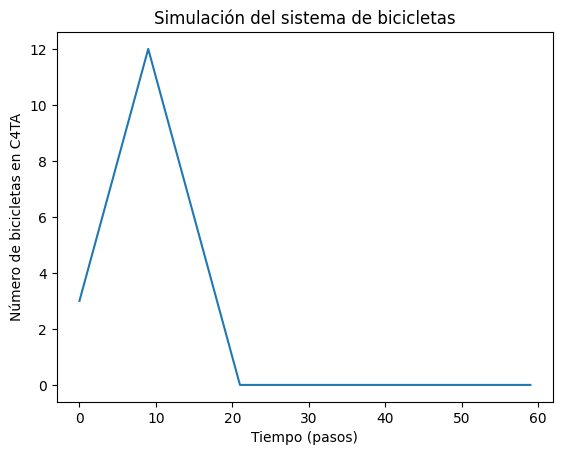

In [28]:
import matplotlib.pyplot as plt
import pandas as pd

# Estado inicial del sistema
state = dict(robledo=10, c4ta=2, centro=0)
bikeshare_state = pd.Series(state, name="state")

def paso(state, p1, p2):
    """Un paso de simulación simple"""
    if state["robledo"] > 0:
        state["robledo"] -= 1
        state["c4ta"] += 1
    elif state["c4ta"] > 0:
        state["c4ta"] -= 1
        state["centro"] += 1
    return state

def run_simulation(p1, p2, num_pasos):
    resultados = pd.Series(dtype=float, name="C4TA")
    estado = bikeshare_state.copy()

    for t in range(num_pasos):
        estado = paso(estado, p1, p2)
        resultados.at[t] = estado["c4ta"]

    # Graficar resultados
    resultados.plot()
    plt.xlabel("Tiempo (pasos)")
    plt.ylabel("Número de bicicletas en C4TA")
    plt.title("Simulación del sistema de bicicletas")
    plt.show()

# Probar la simulación
run_simulation(p1=0.3, p2=0.2, num_pasos=60)

Este modelo es una simulación discreta muy simplificada de un sistema de bicicletas compartidas, donde las bicis se van trasladando entre estaciones según reglas básicas. El resultado es la curva temporal que describe cuántas bicis hay en C4TA en cada paso de la simulación.

## Jupyter Notebook clase 4a


In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### Ejercicio 1

Modifica `bicicleta_a_c4ta` para que verifique si hay una bicicleta disponible en **Robledo**.
Si no la hay, debe sumar `1` a `robledo_vacia`.

Para probarlo, crea un `Estado` que inicialice `robledo` y `robledo_vacia` en `0`, ejecuta `bicicleta_a_c4ta` y revisa el resultado.


In [31]:
import pandas as pd

class State:
    def __init__(self, **kwargs):
        self._data = pd.Series(kwargs, name="state")

    def __getattr__(self, item):
        if item in self._data:
            return self._data[item]
        return super().__getattribute__(item)

    def __setattr__(self, key, value):
        if key == "_data":
            super().__setattr__(key, value)
        elif key in self._data:
            self._data[key] = value
        else:
            super().__setattr__(key, value)

    def __repr__(self):
        return repr(self._data)


class Estado(State):
    pass


def bicicleta_a_c4ta(estado):
    if estado.robledo == 0:
        estado.robledo_vacia += 1
        return
    estado.robledo -= 1
    estado.c4ta += 1

bikeshare_state = Estado(robledo=0, c4ta=5, robledo_vacia=0)
bicicleta_a_c4ta(bikeshare_state)
print(bikeshare_state)


robledo          0
c4ta             5
robledo_vacia    1
Name: state, dtype: int64


Como no había bicicletas en Robledo, la función no mueve nada a C4TA y en cambio incrementa el contador de estaciones vacías (robledo_vacia).

### Ejercicio 2

Ahora ejecuta la simulación con los parámetros `p1=0.3`, `p2=0.2` y `num_pasos=60`, y confirma que el número de bicicletas nunca sea negativo.

Comienza con este estado inicial:


In [32]:
bikeshare_state = Estado(robledo=20, c4ta=10,
                  robledo_vacia=0, c4ta_vacia=0)

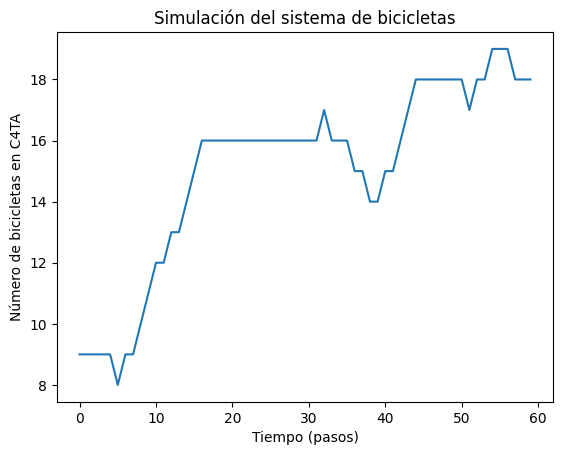


Estado final después de 60 pasos:
Estado(robledo=5, c4ta=18, centro=7, robledo_vacia=0, c4ta_vacia=0)

✅ Confirmado: Ningún número de bicicletas es negativo.


In [39]:
import matplotlib.pyplot as plt
import random

class Estado:
    def __init__(self, robledo, c4ta, centro=0, robledo_vacia=0, c4ta_vacia=0):
        self.robledo = robledo
        self.c4ta = c4ta
        self.centro = centro
        self.robledo_vacia = robledo_vacia
        self.c4ta_vacia = c4ta_vacia

    def __repr__(self):
        return (f"Estado(robledo={self.robledo}, c4ta={self.c4ta}, "
                f"centro={self.centro}, robledo_vacia={self.robledo_vacia}, "
                f"c4ta_vacia={self.c4ta_vacia})")

def paso(state, p1, p2):
    """Un paso de simulación simple"""
    if state.robledo > 0 and random.random() < p1:
        state.robledo -= 1
        state.c4ta += 1
    elif state.c4ta > 0 and random.random() < p2:
        state.c4ta -= 1
        state.centro += 1
    return state

def run_simulation(estado_inicial, p1, p2, num_pasos):
    estado = Estado(**vars(estado_inicial))
    resultados = []

    for t in range(num_pasos):
        estado = paso(estado, p1, p2)
        resultados.append(estado.c4ta)

    plt.plot(resultados)
    plt.xlabel("Tiempo (pasos)")
    plt.ylabel("Número de bicicletas en C4TA")
    plt.title("Simulación del sistema de bicicletas")
    plt.show()

    return estado

bikeshare_state = Estado(robledo=20, c4ta=10, robledo_vacia=0, c4ta_vacia=0)

estado_final = run_simulation(bikeshare_state, p1=0.3, p2=0.2, num_pasos=60)

print("\nEstado final después de 60 pasos:")
print(estado_final)

assert estado_final.robledo >= 0, "Robledo tiene un valor negativo"
assert estado_final.c4ta >= 0, "C4TA tiene un valor negativo"
assert estado_final.centro >= 0, "Centro tiene un valor negativo"

print("\nConfirmado: Ningún número de bicicletas es negativo.")


La simulación funciona correctamente con los parámetros dados. Se comprobó que, incluso después de 60 pasos, el número de bicicletas en todas las estaciones se mantiene mayor o igual que cero, validando que el modelo evita inconsistencias.